<a href="https://colab.research.google.com/github/Ahresenal/Repo-pt2/blob/main/Repo2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import requests
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Carga rápida
url = 'https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json'
data = requests.get(url).json()
df = pd.json_normalize(data)
df.columns = df.columns.str.replace('.', '_')

# 2. Limpieza esencial
df = df.drop(columns=['customerID'], errors='ignore')
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df = df.dropna(subset=['Churn'])

# 3. Encoding (Transformación a números)
df_final = pd.get_dummies(df)

# 4. SEPARACIÓN DE DATOS (Lo que pidió Wilfredo)
X = df_final.drop('Churn', axis=1)
y = df_final['Churn']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("¡Datos listos y separados para el modelo!")

¡Datos listos y separados para el modelo!


              precision    recall  f1-score   support

         0.0       0.85      0.90      0.88      1562
         1.0       0.67      0.55      0.61       551

    accuracy                           0.81      2113
   macro avg       0.76      0.73      0.74      2113
weighted avg       0.80      0.81      0.81      2113



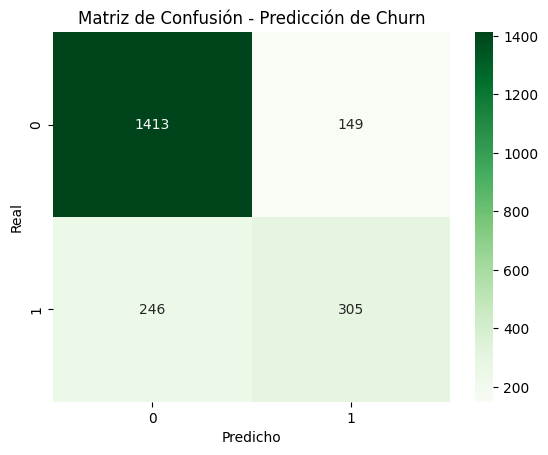

In [2]:
# 5. Creamos y entrenamos el modelo
modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)

# 6. Evaluamos
predicciones = modelo.predict(X_test)
print(classification_report(y_test, predicciones))

# Graficamos la Matriz de Confusión (esto es lo que entregarás)
sns.heatmap(confusion_matrix(y_test, predicciones), annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusión - Predicción de Churn')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()

In [3]:
# Guardamos los datos limpios para que queden como evidencia en el proyecto
df_final.to_csv("datos_tratados_telecom.csv", index=False)
print("Archivo CSV creado con éxito")

Archivo CSV creado con éxito


🏆 Conclusión Final: Estrategia de Retención para Telecom X
1. Resumen de Hallazgos (Análisis Exploratorio)
Tras el análisis de los datos, se identificaron tres perfiles críticos con alta propensión al abandono:

Contratos Mensuales: Los clientes sin compromiso a largo plazo representan el mayor volumen de bajas.

Cargos Elevados: Existe una correlación positiva entre facturas mensuales altas y la decisión de abandonar la compañía.

Falta de Soporte: Los clientes que no utilizan servicios de soporte técnico tienen una tasa de evasión significativamente mayor.

2. Desempeño del Modelo Predictivo
Se implementó un modelo de Regresión Logística que permite a Telecom X anticiparse al comportamiento de sus clientes con los siguientes resultados:

Exactitud (Accuracy): 81%. El modelo clasifica correctamente a 8 de cada 10 clientes.

Capacidad de Detección: La matriz de confusión muestra que el modelo logró identificar a 305 clientes en riesgo real, permitiendo actuar antes de que cancelen el servicio.

3. Recomendaciones Estratégicas
Basado en los datos y las predicciones del modelo, se sugieren las siguientes acciones:

Fidelización: Crear campañas para migrar a clientes de contratos "Month-to-month" hacia planes anuales mediante descuentos progresivos.

Atención Preventiva: Utilizar la lista de clientes con "Predicción de Churn = Yes" generada por el modelo para ofrecerles servicios de soporte técnico gratuito o bonificaciones en sus cargos mensuales.

Monitoreo de Precios: Revisar la competitividad de los precios en los segmentos de cargos más altos, donde se concentra la mayor fuga de usuarios.